# Анализ системы метрик приложения

К началу лета в приложении Procrastinate Pro+, которое предоставляет пользователям доступ к развлекательному контенту: видео, подкастам и блогам, появился новый вид контента — спортивный. С его помощью менеджеры стремятся расширить аудиторию, добавив в неё пользователей, которые увлекаются спортом и здоровым образом жизни.

К запуску нового контента была скорректирована маркетинговая стратегия привлечения пользователей. Согласно бизнес-модели продукта, привлечение должно окупиться за первые 28 дней (4 недели).

После запуска нового контента и изменения стратегии интерес к продукту в целом вырос, но выручка начала стагнировать. Нужно разобраться, почему это происходит.

Задачи:
- провести анализ юнит-экономики продукта в динамике за первые 28 дней;
- разобраться в причинах стагнации выручки;
- определить, какие источники привлечения приносят прибыль, а какие не выходят на уровень окупаемости;
- дать рекомендации отделу маркетинга.


### Данные

В нашем распоряжении есть данные о посещениях приложения, покупках и расходах на маркетинг.
Данные собраны в трёх датасетах.

1. Датасет `ppro_visits.csv` — информация о посещениях приложения пользователями, которые зарегистрировались с 1 апреля 2024 года по 30 ноября 2024 года:
    - `user_id` — уникальный идентификатор пользователя;
    - `region` — страна пользователя;
    - `device` — категория устройства пользователя;
    - `channel` — идентификатор рекламного источника, из которого пришёл пользователь;
    - `session_start` — дата и время начала сессии;
    - `session_end` — дата и время окончания сессии.

2. Датасет `ppro_orders.csv` — информация о покупках:
    - `user_id` — уникальный идентификатор пользователя, который сделал покупку;
    - `event_dt` — дата и время покупки;
    - `revenue` — выручка.

3. Датасет `ppro_costs.csv` — информация о затратах на маркетинг:
    - `dt` — дата
    - `channel` — идентификатор рекламного источника;
    - `costs` — затраты на этот рекламный источник в этот день.
    
### План проекта
- Загрузить и предобработать данные.
- Подготовить данные для когортного анализа.
- Рассчитать и проанализировать метрики вовлечённости в продукт.
- Рассчитать и проанализировать финансовые метрики CAC, LTV и ROI за первые 28 дней с момента привлечения.
- Исследовать метрики в разрезе источника привлечения.
- Рассчитать период окупаемости маркетинговых вложений.
- Сформулировать выводы и рекомендации.


## Загрузка и предобработка данных

Загружаем данные и получаем основную информацию о них. Проводим необходимую предобработку.

In [1]:
# Импортируем бибилиотеки
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

In [2]:
# Загружаем датасеты и сразу преобразовываем столбцы с датами в datetime
visits = pd.read_csv('ppro_visits.csv', parse_dates=['session_start','session_end'])
orders = pd.read_csv('ppro_orders.csv', parse_dates=['event_dt'])
costs = pd.read_csv('ppro_costs.csv', parse_dates=['dt']) 

- Посмотрим внутрянку датасетов

In [3]:
# Основная информация о датасете
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161865 entries, 0 to 161864
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        161865 non-null  int64         
 1   region         161865 non-null  object        
 2   device         161865 non-null  object        
 3   channel        161865 non-null  object        
 4   session_start  161865 non-null  datetime64[ns]
 5   session_end    161865 non-null  datetime64[ns]
dtypes: datetime64[ns](2), int64(1), object(3)
memory usage: 7.4+ MB


In [4]:
# Первые пять строк
visits.head()

,user_id,region,device,channel,session_start,session_end
0,631105188566,India,desktop,MediaTornado,2024-04-01 03:48:00,2024-04-01 04:19:00
1,892885906464,India,tv,RocketSuperAds,2024-04-01 00:47:00,2024-04-01 01:14:00
2,517003690029,India,mobile,MediaTornado,2024-04-01 17:31:00,2024-04-01 17:53:00
3,185156659289,India,mobile,MediaTornado,2024-04-01 14:36:00,2024-04-01 14:51:00
4,409503040345,India,mobile,RocketSuperAds,2024-04-01 08:25:00,2024-04-01 08:45:00


In [5]:
# Количество дупликатов по всем столбцам
visits.duplicated().sum()

0

- В датасете `visits` 6 столбцов и 161 865 строк без пропусков и дупликатов.
- Поле `user_id` имеет тип `int64`, остальные - `object`.
- Можно проверить количество уникальных значений в поле `region`.
- Поля `device`, `channel` и `region` (если там больше одного значения) можно переделать в тип `category`.

In [6]:
# Проверим уникальные значения в поле с регионом
visits['region'].unique()

array(['India'], dtype=object)

- Можно удалить поле `region`, так как там только одно значение, т.е. оно не несет никакой полезной информации.

In [7]:
# Можно удалить этот столбец за ненадобностью
visits.drop(columns=['region'], inplace=True)

- Преобразуем поля в подходящий тип

In [8]:
# Преобразовываем поля с типом устройства и каналом привлечения из 'object' в 'category'
visits[['device', 'channel']] = visits[['device', 'channel']].astype('category')

# Проверяем результат предобработки
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161865 entries, 0 to 161864
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   user_id        161865 non-null  int64         
 1   device         161865 non-null  category      
 2   channel        161865 non-null  category      
 3   session_start  161865 non-null  datetime64[ns]
 4   session_end    161865 non-null  datetime64[ns]
dtypes: category(2), datetime64[ns](2), int64(1)
memory usage: 4.0 MB


- Был удален столбец `region`.
- Теперь столбцы `device` и `channel` имеют тип `category`.
- Всего осталось 5 столбцов и 161 865 строк.

---

- Рассмотрим датасет `orders`

In [9]:
# Общая информация
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33893 entries, 0 to 33892
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   33893 non-null  int64         
 1   event_dt  33893 non-null  datetime64[ns]
 2   revenue   33893 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 794.5 KB


In [10]:
# Первые пять строк
orders.head()

,user_id,event_dt,revenue
0,771951256319,2024-04-01 05:56:26,2.99
1,829942381059,2024-04-01 14:55:02,2.99
2,727879856738,2024-04-01 22:15:09,14.99
3,481270888930,2024-04-01 06:05:14,2.99
4,844695029762,2024-04-01 01:19:52,2.99


In [11]:
# Дупликаты по полям user_id и event_id
orders.duplicated(subset=['user_id', 'event_dt']).sum()

0

- В датасете `orders` 3 столбца и 33 893 строки без дупликатов и пропусков.
- Типы данных столбцов адекватны их содержимому.

---

- Рассмотрим датасет `costs`

In [12]:
# Общая информация
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   dt       976 non-null    datetime64[ns]
 1   channel  976 non-null    object        
 2   costs    976 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 23.0+ KB


In [13]:
# Первые пять строк
costs.head()

,dt,channel,costs
0,2024-04-01,FaceBoom,124.938874
1,2024-04-02,FaceBoom,88.147779
2,2024-04-03,FaceBoom,120.779457
3,2024-04-04,FaceBoom,98.981253
4,2024-04-05,FaceBoom,109.044760


In [14]:
# Количество дупликатов по столбцам с датой и каналом привлечения
costs.duplicated(subset=['dt', 'channel']).sum()

0

- В датасете `costs` 3 столбца и 976 строк без пропусков и дупликатов.
- Столбец `channel`, по аналогии с таким же столбцом из датасета `visits`, можно поменять с `object` на `category`.

In [15]:
# Меняем типы столбцов
costs['channel'] = costs['channel'].astype('category')

# Проверяем
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   dt       976 non-null    datetime64[ns]
 1   channel  976 non-null    category      
 2   costs    976 non-null    float64       
dtypes: category(1), datetime64[ns](1), float64(1)
memory usage: 16.5 KB


---

- Проверим данные в датасетах на соответствие

In [16]:
# Сравним списки каналов в датасетах costs и visits
set(costs.channel.unique()) == set(visits.channel.unique())

True

In [17]:
# Есть ли несоответствие в списках пользователей в датасетах orders и b visits
orders.user_id.isin(~visits.user_id.unique()).sum()

0

In [18]:
# Диапазон дат
print(f'''
Посмотрим диапазон дат во всех датсетах:
Даты visits: от - {visits.session_start.dt.to_period('D').min()}, до - {visits.session_start.dt.to_period('D').max()}
Даты orders: от - {orders.event_dt.dt.to_period('D').min()}, до - {orders.event_dt.dt.to_period('D').max()}
Даты costs: от - {costs.dt.dt.to_period('D').min()}, до - {costs.dt.dt.to_period('D').max()}
''')


Посмотрим диапазон дат во всех датсетах:
Даты visits: от - 2024-04-01, до - 2024-11-30
Даты orders: от - 2024-04-01, до - 2024-11-30
Даты costs: от - 2024-04-01, до - 2024-11-30



## Подготовка данных к когортному анализу

Подготовим данные к когортному анализу с учётом того, что мы будем изучать окупаемость привлечения пользователей за первые 28 дней.

Для каждого пользователя найдём:
- дату первой сессии (дата привлечения пользователя, `first_dt`);
- канал привлечения (`first_channel`);
- стоимость привлечения пользователя (`cac`).

Результаты сохраним в новой таблице `profiles`.

Добавим к данным с событиями и покупками информацию о первом источнике привлечения и дату привлечения пользователя из созданной таблицы. После этого рассчитаем дневной лайфтайм для каждого события или покупки и добавим в таблицу в виде целого числа. В дальнейшем при проведении когортного анализа мы будем использовать информацию о первом источнике привлечения пользователя.

In [19]:
# Отсортируем датасет visits по дате начала сессии и создадим новую таблицу с датой первой сессии и каналом привлечения
visits.sort_values(by='session_start', inplace=True)
profiles = visits.groupby('user_id', as_index=False).agg(
    first_dt = ('session_start', 'first'),
    first_channel = ('channel', 'first')
)

# Округлим дату до дня и посчитаем количество пользователей с группировкой по первой дате и рекламному источнику
profiles['first_dt'] = profiles['first_dt'].dt.to_period('D').dt.to_timestamp()
user_count = profiles.groupby(['first_dt', 'first_channel'], as_index=False).agg(user_count=('user_id', 'nunique'))

# Объедимим таблицы с затратами на меркетинг и количеством пользователей
df_CAC = pd.merge(costs, user_count, left_on=['dt', 'channel'], right_on=['first_dt', 'first_channel'], how='left')

# Вычислим метрику CAC
df_CAC['CAC'] = df_CAC['costs'] / df_CAC['user_count']

# Дополним созданную в начале таблицу метрикой CAC
profiles = pd.merge(profiles, df_CAC[['first_dt', 'first_channel', 'CAC']], on=['first_dt', 'first_channel'])

profiles.sample(10, random_state=1)

,user_id,first_dt,first_channel,CAC
73239,579788237398,2024-07-18,TipTop,1.785840
69525,334456073944,2024-07-28,RocketSuperAds,0.583333
11971,523630519495,2024-08-26,MediaTornado,0.267451
17476,575168295615,2024-06-14,MediaTornado,0.288043
69326,958318038698,2024-04-18,TipTop,0.757812
28940,173916507905,2024-10-26,TipTop,2.842887
50185,267337134555,2024-06-08,FaceBoom,1.164070
1941,951658264688,2024-08-21,MediaTornado,0.262119
71464,605835962056,2024-05-17,TipTop,0.882292
53780,454212480256,2024-07-03,MediaTornado,0.247943


In [20]:
# Дополним датасеты visits и orders полями first_dt и first_channel из таблицы profiles
visits = pd.merge(
    visits,
    profiles.drop(columns='CAC'),
    how='left',
    on='user_id'
)

orders = pd.merge(
    orders,
    profiles.drop(columns='CAC'),
    how='left',
    on='user_id'
)

# Если в дальнейшей мы будем использовать только первый источник привлечения, то поле channel из датасета visits можно удалить
visits.drop(columns='channel', inplace=True)

In [21]:
# Добавим в датасеты visits и orders поле с лайфтаймом в днях для событий и покупок
visits['days_delta'] = (
    visits['session_start'].dt.to_period('D').astype('int') -
    visits['first_dt'].dt.to_period('D').astype('int')
)

orders['days_delta'] = (
    orders['event_dt'].dt.to_period('D').astype('int') -
    orders['first_dt'].dt.to_period('D').astype('int')
)

In [22]:
visits.sample(10, random_state=1)

,user_id,device,session_start,session_end,first_dt,first_channel,days_delta
23387,915300684878,mobile,2024-05-16 02:17:00,2024-05-16 03:06:00,2024-05-15,FaceBoom,1
90677,368945802783,mobile,2024-09-01 20:12:00,2024-09-01 20:33:00,2024-07-16,TipTop,47
70901,925290493116,tv,2024-08-03 20:32:00,2024-08-03 20:42:00,2024-08-03,RocketSuperAds,0
13630,933197593487,mobile,2024-04-29 03:16:00,2024-04-29 04:04:00,2024-04-28,RocketSuperAds,1
109690,154560519873,desktop,2024-09-28 07:50:00,2024-09-28 09:10:00,2024-09-28,FaceBoom,0
56435,487696000369,mobile,2024-07-10 23:27:00,2024-07-11 00:14:00,2024-06-30,TipTop,10
120715,313921556014,mobile,2024-10-12 08:22:00,2024-10-12 08:32:00,2024-08-18,TipTop,55
118437,848493664392,mobile,2024-10-09 08:14:00,2024-10-09 08:35:00,2024-05-29,MediaTornado,133
159027,583222546932,desktop,2024-11-27 18:13:00,2024-11-27 18:44:00,2024-11-24,TipTop,3
100233,976599632643,mobile,2024-09-15 22:01:00,2024-09-15 22:29:00,2024-09-15,RocketSuperAds,0


In [23]:
orders.sample(10, random_state=1)

,user_id,event_dt,revenue,first_dt,first_channel,days_delta
11433,976908444963,2024-07-30 20:36:02,2.99,2024-07-30,RocketSuperAds,0
20565,329332445968,2024-09-26 19:33:11,4.49,2024-05-05,RocketSuperAds,144
10064,619256725222,2024-07-21 21:40:37,2.99,2024-06-11,RocketSuperAds,40
9084,482296496636,2024-07-13 08:15:38,2.99,2024-07-12,TipTop,1
22341,571450492066,2024-10-05 06:32:20,2.99,2024-09-21,TipTop,14
5798,840361965485,2024-06-15 13:21:54,2.99,2024-05-17,TipTop,29
25787,400080967166,2024-10-23 04:22:55,4.49,2024-10-23,FaceBoom,0
31989,402844697175,2024-11-22 13:24:20,2.99,2024-11-08,TipTop,14
14958,840920558702,2024-08-23 14:27:28,2.99,2024-08-08,FaceBoom,15
9467,773979493287,2024-07-16 12:32:05,2.99,2024-07-13,RocketSuperAds,3


- Создали таблицу `profiles` с информацией о первом дне активности (`first_dt`), первом источнике привлечения (`first_channel`) и `CAC` для каждого пользователя.
- Добавили в начальные датасеты `visits` и `orders` информацию о первом дне активности и первом источнике привлечения, а так же вычислили лайфтайм в днях для каждого события и покупки.

## Анализ месячной динамики основных метрик продукта

---

**Задача 1:**
- Начнём анализ данных с изучения динамики активности пользователей и их вовлечённости в продукт. Рассчитаем по всем данным значения DAU, MAU и Stickiness и визуализируем их. Активными будем считать всех пользователей, которые взаимодействовали с приложением.

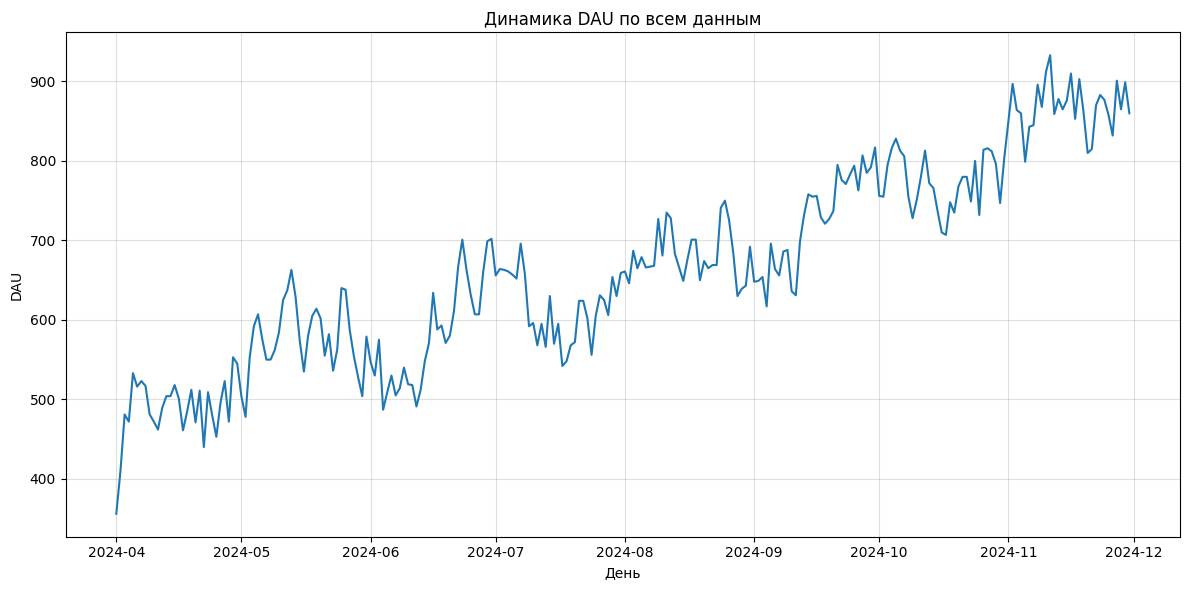

In [24]:
# Добавим новые поля для вычисления метрик
visits['session_day'] = visits['session_start'].dt.to_period('D').dt.to_timestamp()
visits['session_month'] = visits['session_start'].dt.to_period('M').dt.to_timestamp()

# Группируем сразу и по месяцу, чтобы потом посчитать среднемесячный DAU
dau_all = visits.groupby(['session_day', 'session_month'], as_index=False).agg(dau=('user_id', 'nunique'))

# Рисуем график DAU
plt.figure(figsize=(12,6))
sns.lineplot(
    data=dau_all,
    x='session_day',
    y='dau'
)

# Настройки отображения
plt.grid(alpha=.4)
plt.title('Динамика DAU по всем данным')
plt.xlabel('День')
plt.ylabel('DAU')
plt.tight_layout()

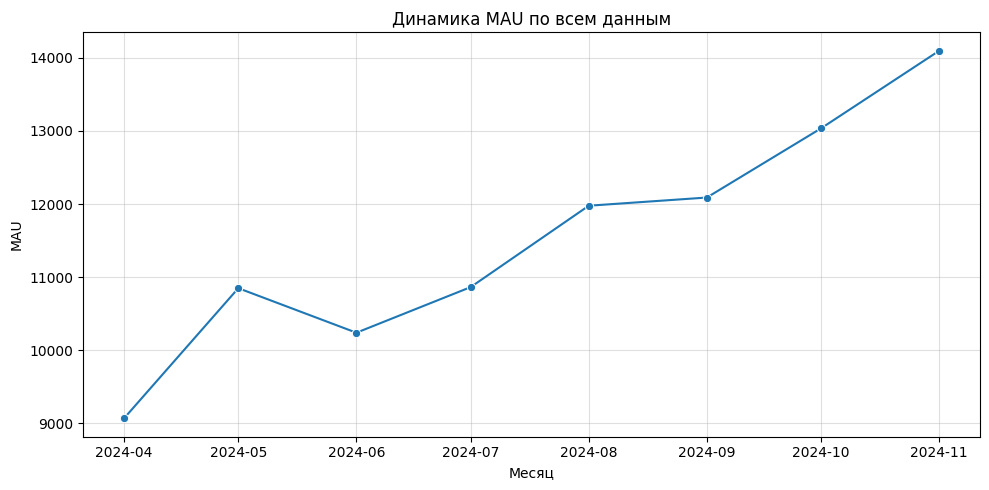

In [25]:
# Считаем MAU по всем данным
mau_all = visits.groupby('session_month', as_index=False).agg(mau=('user_id', 'nunique'))

# Рисуем график MAU
plt.figure(figsize=(10,5))
sns.lineplot(
    data=mau_all,
    x='session_month',
    y='mau',
    marker='o'
)

# Настройки отображения
plt.grid(alpha=.4)
plt.title('Динамика MAU по всем данным')
plt.xlabel('Месяц')
plt.ylabel('MAU')
plt.tight_layout()

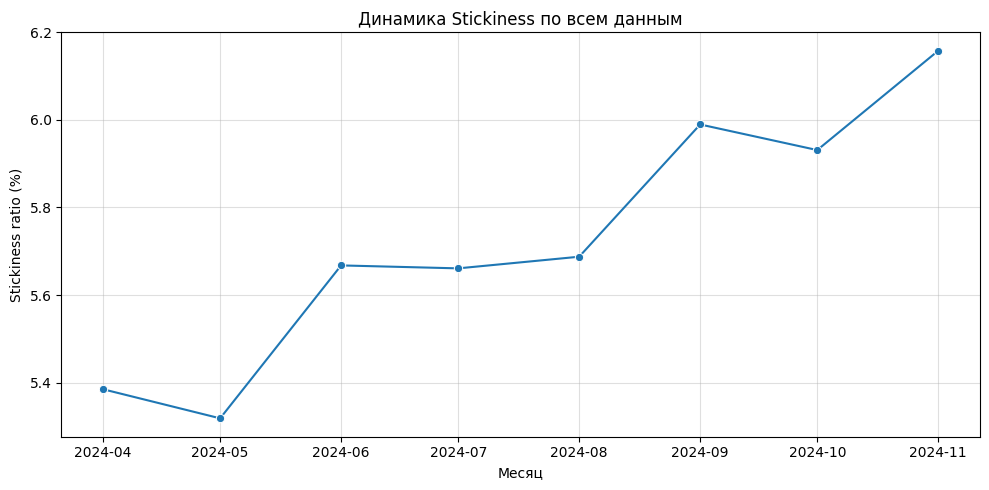

In [26]:
# Считаем средний DAU за месяц
stickiness = dau_all.groupby('session_month', as_index=False).agg(avg_dau=('dau', 'mean'))

# Соединяем датафреймы stickiness и mau_all, чтобы посчитать Stickiness ratio
stickiness = pd.merge(stickiness, mau_all, on='session_month')
stickiness['stickiness_ratio'] = stickiness['avg_dau'] / stickiness['mau'] * 100

# Рисуем график Stickiness
plt.figure(figsize=(10,5))
sns.lineplot(
    data=stickiness,
    x='session_month',
    y='stickiness_ratio',
    marker='o'
)

# Настройки отображения
plt.grid(alpha=.4)
plt.title('Динамика Stickiness по всем данным')
plt.xlabel('Месяц')
plt.ylabel('Stickiness ratio (%)')
plt.tight_layout()

**Выводы:**
- На графике `DAU`, несмотря на колебания, заметен положительный тренд, но с просадкой в начале лета. Видимо это связано с появлением новго контента.
- На графике `MAU` видно, что было заметное снижение метрики в июне по сравнению с маем, но потом, после появления нового контента, почти стабильно росла. Замедление роста было только в сентябре.
- Динамика `Stickiness`, в свою очередь, так же показывает зависимость от нововведений. Виден сильный рост с мая по июнь. С июня по август метрика почти не менялась, а в рост пошла в сентябре. Затем, после небольшого падения в сентябре, в ноябре опять выросла.

---

**Задача 2:**
В разрезе каждого месяца привлечения новых пользователей рассчитаем:
- Среднюю стоимость привлечения пользователя (CAC).
- Усредненное значение LTV и ROI для всех пользователей когорты с учётом покупок, совершённых за 28 дней с момента привлечения.

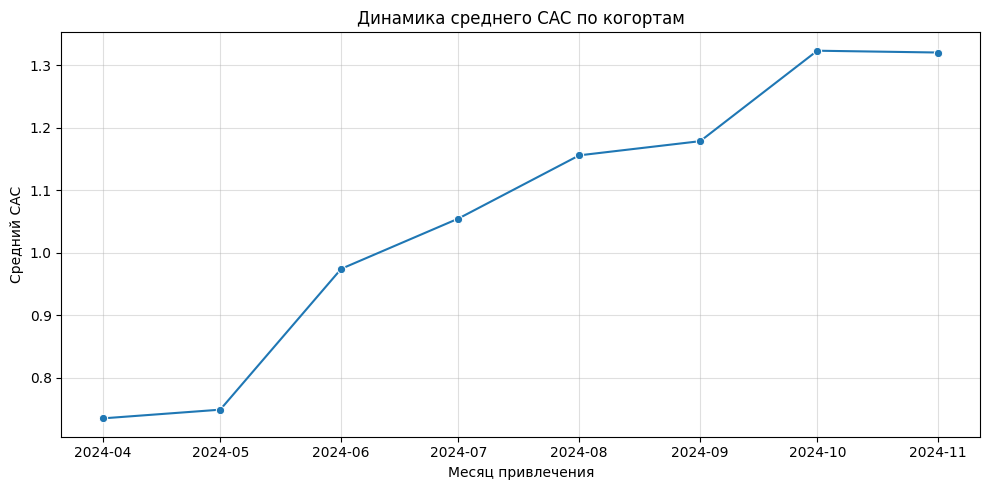

In [27]:
# Рассчитываем средний CAC и количество пользователей для всех когорт
profiles['first_month'] = profiles['first_dt'].dt.to_period('M').dt.to_timestamp()
cohort_CAC = profiles.groupby('first_month', as_index=False).agg(avg_CAC=('CAC', 'mean'),
                                                                 user_count=('user_id', 'nunique')) # чтобы потом посчитать LTV

# Рисуем график CAC
plt.figure(figsize=(10,5))
sns.lineplot(
    data=cohort_CAC,
    x='first_month',
    y='avg_CAC',
    marker='o'
)

# Настройки отображения
plt.grid(alpha=.4)
plt.title('Динамика среднего CAC по когортам')
plt.xlabel('Месяц привлечения')
plt.ylabel('Средний CAC')
plt.tight_layout()

In [28]:
# Добавляем в датасет orders поле с месяцем привлечения
orders['first_month'] = orders['first_dt'].dt.to_period('M').dt.to_timestamp()

# Сортируем по месяцу привлечения и дням активности и фильтруем первые 28 дней
orders.sort_values(by=['first_month', 'days_delta'], inplace=True)
orders_filtered = orders[orders['days_delta'].between(0,28)]

# Группируем по первому месяцу
orders_group = orders_filtered.groupby('first_month', as_index=False)['revenue'].sum()

# Объединяем получившуюся таблицу с cohort_CAC по первому месяцу активности из прошлой ячейки
cohort_LTV_CAC = pd.merge(orders_group, cohort_CAC, on='first_month')

# Делим сумму выручки на общее количество активных пользователей в когорте
cohort_LTV_CAC['LTV'] = cohort_LTV_CAC['revenue'] / cohort_LTV_CAC['user_count']

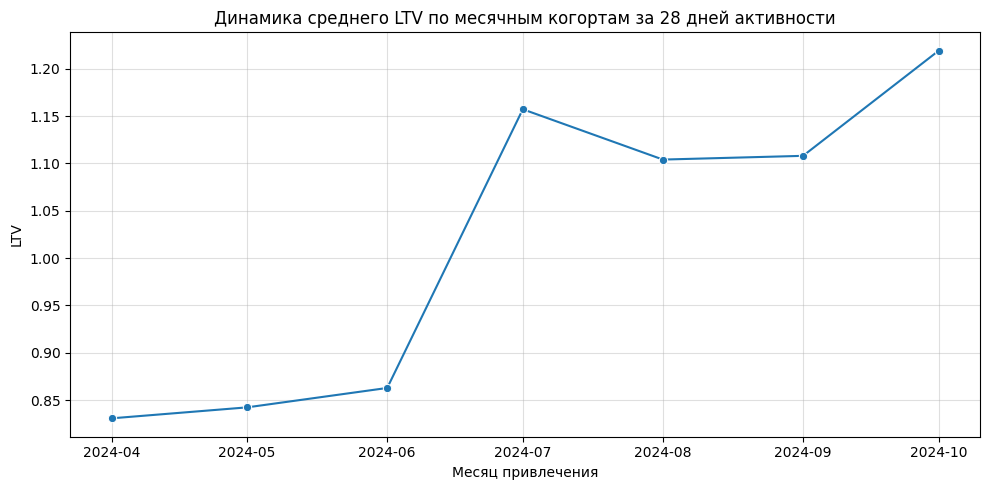

In [29]:
# Рисуем график LTV
plt.figure(figsize=(10,5))
sns.lineplot(
    data=cohort_LTV_CAC[cohort_LTV_CAC['first_month']!='2024-11'], # Убираем последнюю когорту, чтобы избежать искажения данных
    x='first_month',
    y='LTV',
    marker='o'
)

# Настройки отображения
plt.grid(alpha=.4)
plt.title('Динамика среднего LTV по месячным когортам за 28 дней активности')
plt.xlabel('Месяц привлечения')
plt.ylabel('LTV')
plt.tight_layout()

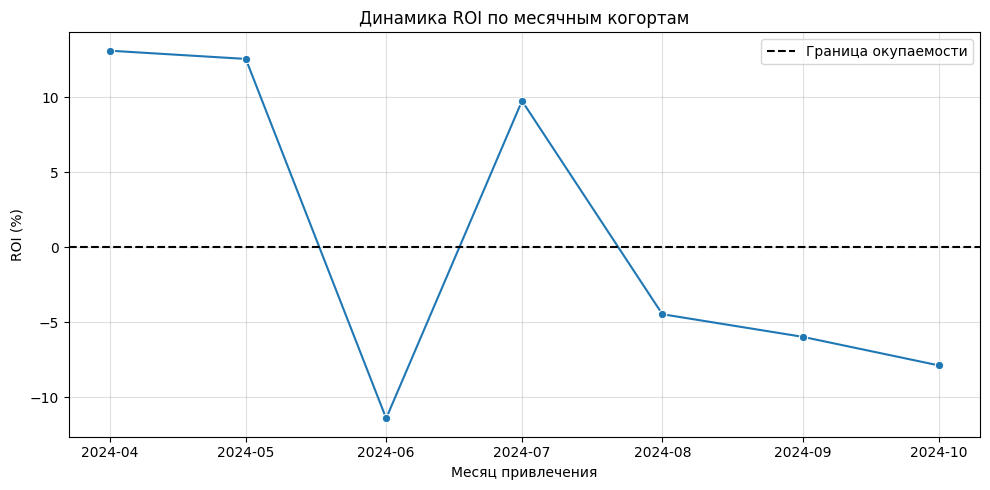

In [30]:
# Считаем ROI
cohort_LTV_CAC['ROI'] = (cohort_LTV_CAC['LTV'] - cohort_LTV_CAC['avg_CAC']) / cohort_LTV_CAC['avg_CAC'] * 100

# Рисуем график
plt.figure(figsize=(10,5))
sns.lineplot(
    data=cohort_LTV_CAC[cohort_LTV_CAC['first_month']!='2024-11'], # Убираем последнюю когорту, чтобы избежать искажения данных,
    x='first_month',
    y='ROI',
    marker='o'
)

# Рисуем линию окупаемости y=0
plt.axhline(y=0, color='black', linestyle='--', label='Граница окупаемости')

# Настройки отображения
plt.grid(alpha=.4)
plt.legend()
plt.title('Динамика ROI по месячным когортам')
plt.xlabel('Месяц привлечения')
plt.ylabel('ROI (%)')
plt.tight_layout()

**Выводы:**
- Метрика `CAC` начала заметно расти для когорт с момента появления нововведений. В сентябрьской когорте рост слегка замедлился, а в ноябрьской - стагнировал.
- Из пяти выбранных мной когрот метрика `LTV` пересекла черту `CAC` только в двух - апрельской и июльской. При этом все, кроме ноябрьской, показывают устойчивый рост. Метрика ноябрьской когорты после 25го дня активности как-будто уже вообще не растет.
- На графике `ROI` для всех когорт видно, что границу окупаемости в районе 20го дня пересекли только три когорты: апрельская и майская (до нововведений), и июльская (после нововведений). Для ноябрьской когорты метрика растет очень слабо и как-будто вообще не стремится к границе окупаемости. Остальные когорты, хоть и не успели окупиться за 28 дней, но, судя по всему, окупятся позднее.

## Анализ метрик в разрезе источника привлечения

---

Теперь необходимо разобраться, какие источники привлечения перспективны, а какие за 28 дней не окупились.

**Задача 1:** Определим самые популярные источники привлечения:
- Посчитаем общее число привлечённых пользователей для каждого источника.
- Визуализируем динамику набора новых пользователей по дням в каждом источнике.
- Рассчитаем и визуализируем динамику DAU, MAU и Stickiness по источникам привлечения.

In [31]:
# Считаем общее число пользователей для каждого источника
channels_grouped = profiles.groupby('first_channel').agg(user_count=('user_id', 'count')).sort_values('user_count', ascending=False)
channels_grouped

,user_count
first_channel,
FaceBoom,28401
TipTop,18118
RocketSuperAds,14257
MediaTornado,14080


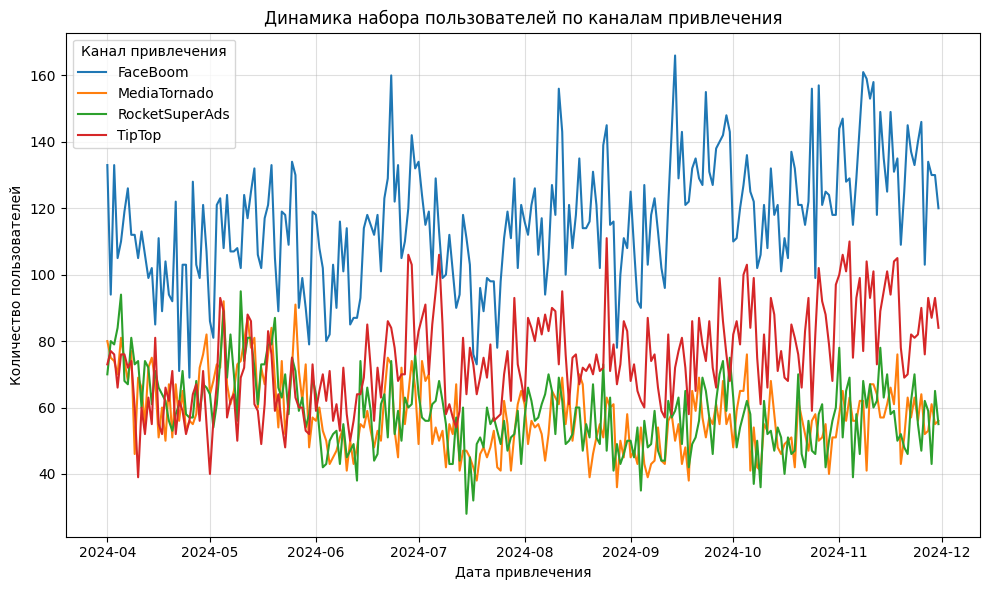

In [32]:
# Считаем уникальных пользователей для каждого канала по каждому дню
channels_dynamic = profiles.groupby(['first_channel', 'first_dt'], as_index=False).agg(user_count=('user_id', 'nunique'))
channels_dynamic.sort_values(by=['first_channel', 'first_dt'], inplace=True)

# Рисуем график динамики набора пользователей
plt.figure(figsize=(10,6))
sns.lineplot(
    data=channels_dynamic,
    x='first_dt',
    y='user_count',
    hue='first_channel'
)

# Настройки отображения
plt.grid(alpha=.4)
plt.legend(title='Канал привлечения')
plt.title('Динамика набора пользователей по каналам привлечения')
plt.xlabel('Дата привлечения')
plt.ylabel('Количество пользователей')
plt.tight_layout()

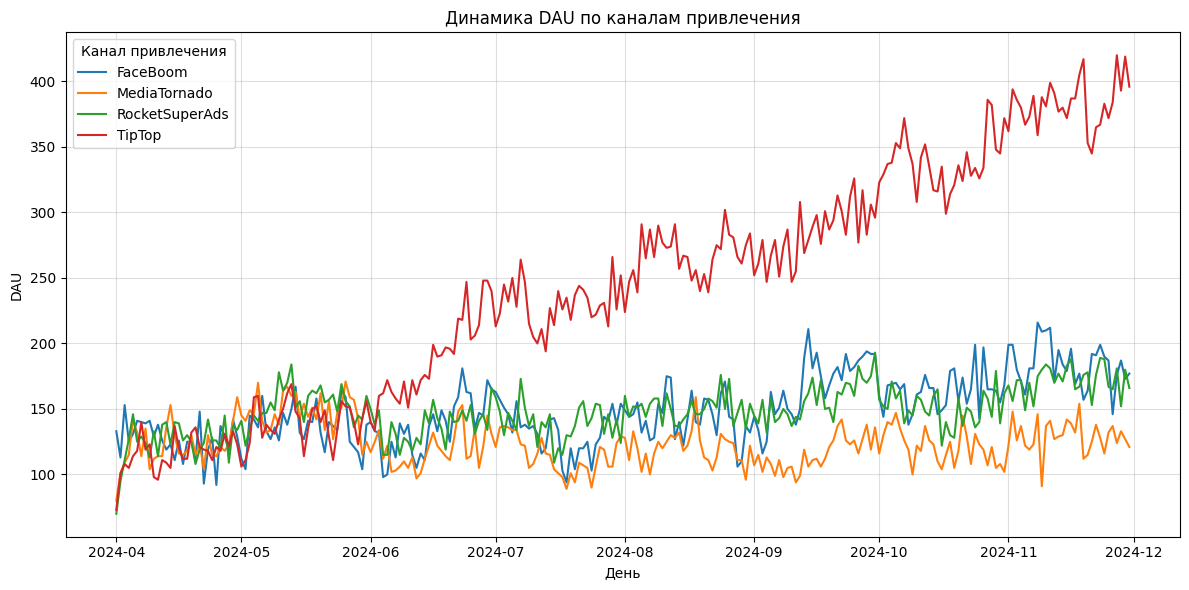

In [33]:
# Считаем DAU для каналов привлечения
dau_channels = visits.groupby(['first_channel', 'session_day', 'session_month'], as_index=False).agg(dau=('user_id', 'nunique'))

# Рисуем график DAU
plt.figure(figsize=(12,6))
sns.lineplot(
    data=dau_channels,
    x='session_day',
    y='dau',
    hue='first_channel'
)

# Настройки отображения
plt.grid(alpha=.4)
plt.legend(title='Канал привлечения')
plt.title('Динамика DAU по каналам привлечения')
plt.xlabel('День')
plt.ylabel('DAU')
plt.tight_layout()

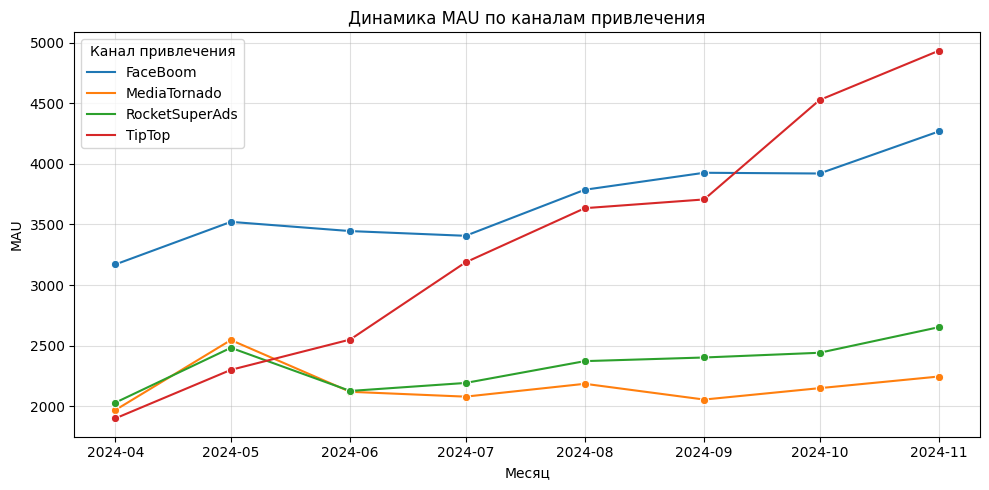

In [34]:
# Считаем MAU для каналов привлечения
mau_channels = visits.groupby(['first_channel', 'session_month'], as_index=False).agg(mau=('user_id', 'nunique'))

# Рисуем график MAU
plt.figure(figsize=(10,5))
sns.lineplot(
    data=mau_channels,
    x='session_month',
    y='mau',
    hue='first_channel',
    marker='o'
)

# Настройки отображения
plt.grid(alpha=.4)
plt.legend(title='Канал привлечения')
plt.title('Динамика MAU по каналам привлечения')
plt.xlabel('Месяц')
plt.ylabel('MAU')
plt.tight_layout()

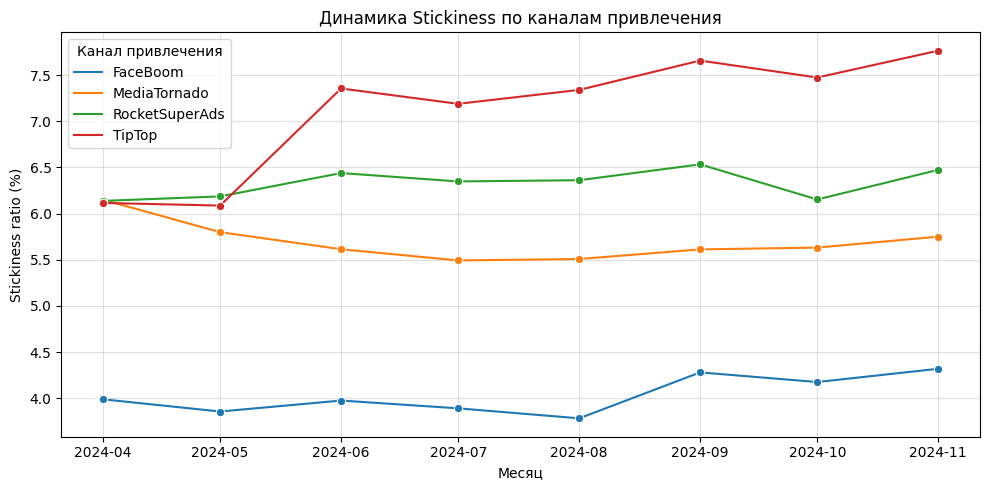

In [35]:
# Считаем средний DAU за месяц для каждого канала привлечения
stickiness_channels = dau_channels.groupby(['first_channel', 'session_month'], as_index=False).agg(avg_dau=('dau', 'mean'))

# Соединяем датафреймы stickiness и mau_channels, чтобы посчитать Stickiness ratio для каждого канала
stickiness_channels = pd.merge(stickiness_channels, mau_channels, on=['first_channel', 'session_month'])
stickiness_channels['stickiness_ratio'] = stickiness_channels['avg_dau'] / stickiness_channels['mau'] * 100

# Рисуем график Stickiness
plt.figure(figsize=(10,5))
sns.lineplot(
    data=stickiness_channels,
    x='session_month',
    y='stickiness_ratio',
    hue='first_channel',
    marker='o'
)

# Настройки отображения
plt.grid(alpha=.4)
plt.legend(title='Канал привлечения')
plt.title('Динамика Stickiness по каналам привлечения')
plt.xlabel('Месяц')
plt.ylabel('Stickiness ratio (%)')
plt.tight_layout()

**Выводы:**
- Канал привлечения `FaceBoom` хоть и является лидером по привлеченным пользователям, по остальным метрикам (`DAU`, `MAU` и `Stickiness`) находится не на первом месте. А по `Stickiness` - на последнем, что говорит о слабой вовлеченности пользователей, пришедших по этому источнику.
- Каналы `RocketSuperAds` и `MediaTornado` привлекли меньше всего пользователей, и по метрике `MAU` тоже находятся на двух последний местах. При этом `DAU` у них на уровне канала `FaceBoom`, а `Stickiness` - больше.
- Канал `TipTop`, в сравнении с другими, принес среднее количество пользователей, но по всем остальным метрикам у него лучшие показатели. Видимо через этот трафик приходит самая лояльная аудитория.

---

**Задача 2:** Изучим динамику изменения метрик на 28-й день в разрезе источника. Для детализации проведем анализ с выделением недельных когорт по дате привлечения. Рассчитаем и визуализируем:
- Скользящее удержание на 14-й день с момента привлечения (за период с 14-го по 28-й день).
- Конверсию в покупку.
- Недельную динамику затрат на маркетинг по каждому источнику привлечения.
- Динамику среднего CAC, значений LTV и ROI.

In [36]:
# Добавим во все основные датасеты поле с первой неделей активности
profiles['first_week'] = profiles['first_dt'].dt.to_period('W').dt.to_timestamp()
visits['first_week'] = visits['first_dt'].dt.to_period('W').dt.to_timestamp()
orders['first_week'] = orders['first_dt'].dt.to_period('W').dt.to_timestamp()

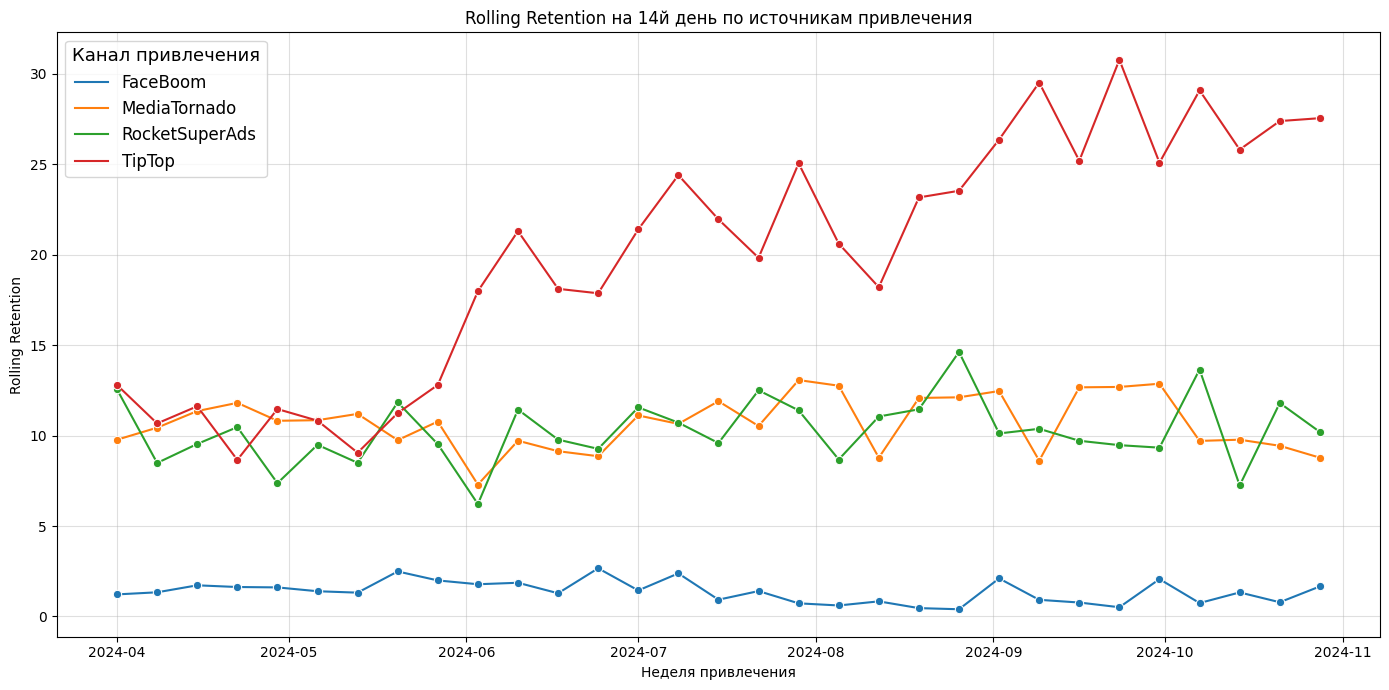

In [37]:
# В отфильтрованном датасете visits по 28ми дням для каждого пользователя находим максимальный день активности
users_retention = visits[visits['days_delta'].between(0,28)].groupby(['user_id', 'first_channel', 'first_week'], as_index=False)['days_delta'].max()

# Добавляем булевый столбец с меткой вернулся ли пользователь на 14й день или позже
users_retention['is_retained_14'] = users_retention['days_delta'] >= 14

# Рассчитываем метрику: группируем по неделе привлечения и каналу и берем среднее из столбца с булевыми значениями
rr_14 = users_retention.groupby(['first_channel', 'first_week'], as_index=False)['is_retained_14'].mean()
rr_14['rr_14'] = rr_14['is_retained_14'] * 100 # Для отображения в процентах

# Так как ноябрь заканчивается в субботу, нужно убрать последние 4 когорты, потому что они не могли успеть накопить 28 дней активности
cohort_list = rr_14['first_week'].unique()[-4:]

# Рисуем график Rolling Retention
plt.figure(figsize=(14, 7))
sns.lineplot(
    data=rr_14[~rr_14['first_week'].isin(cohort_list)],
    x='first_week',
    y='rr_14',
    hue='first_channel',
    marker='o'
)

plt.title('Rolling Retention на 14й день по источникам привлечения')
plt.ylabel('Rolling Retention')
plt.xlabel('Неделя привлечения')
plt.grid(alpha=.4)
plt.legend(title='Канал привлечения', loc='upper left', fontsize=12, title_fontsize=13)
plt.tight_layout()

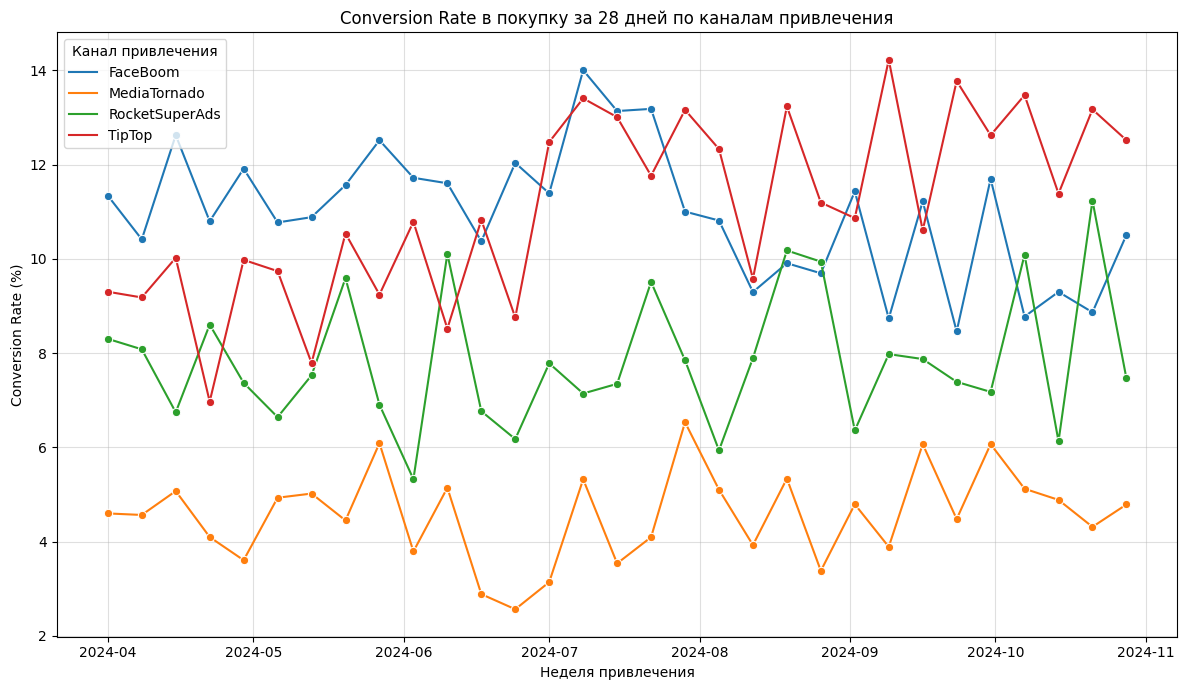

In [38]:
# Фильтруем датасет orders, чтобы оставить пользователей, которые за 28 дней сделали покупку
orders_28 = orders[orders['days_delta'].between(0,28)]

# В датасете profiles делаем булевый столбец с меткой совершил ли пользователь покупку за первые 28 дней
profiles['buyer_28'] = profiles['user_id'].isin(orders_28['user_id'].unique())

# Считаем метрику
cr_28 = profiles.groupby(['first_channel', 'first_week'], as_index=False)['buyer_28'].mean()
cr_28['cr_28'] = cr_28['buyer_28'] * 100

# Рисуем график Conversion Rate в покупку
plt.figure(figsize=(12,7))
sns.lineplot(
    data=cr_28[~cr_28['first_week'].isin(cohort_list)],
    x='first_week',
    y='cr_28',
    hue='first_channel',
    marker='o'
)

# Настройки отображения
plt.grid(alpha=.4)
plt.legend(title='Канал привлечения')
plt.title('Conversion Rate в покупку за 28 дней по каналам привлечения')
plt.xlabel('Неделя привлечения')
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()

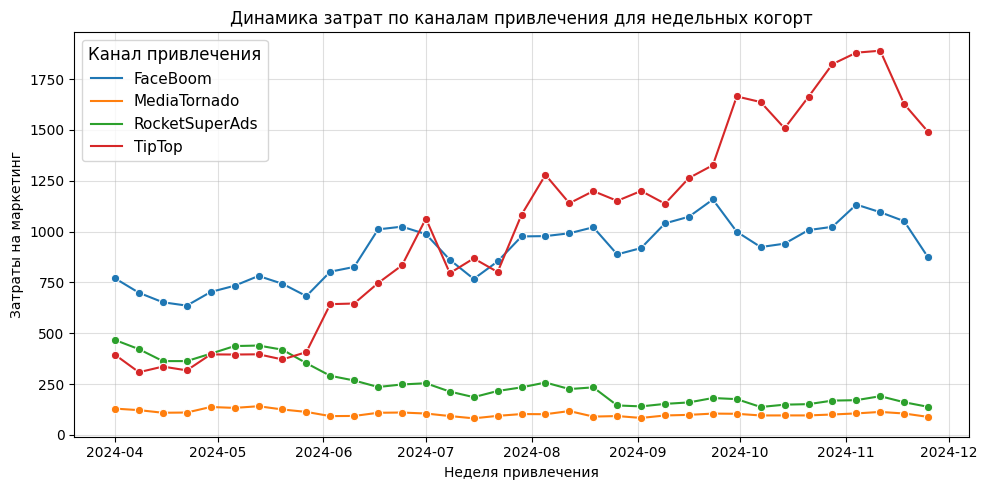

In [39]:
# Считаем затраты на маркетинг путем сложения CAC для каждого канала и каждой недельной когорты
week_costs = profiles.groupby(['first_channel', 'first_week'], as_index=False).agg(costs=('CAC', 'sum'))

# Рисуем график маркетинговых затрат по каналам для недельных когорт
plt.figure(figsize=(10,5))
sns.lineplot(
    data=week_costs,
    x='first_week',
    y='costs',
    hue='first_channel',
    marker='o'
)

# Настройки отображения
plt.grid(alpha=.4)
plt.legend(title='Канал привлечения', fontsize=11, title_fontsize=12)
plt.title('Динамика затрат по каналам привлечения для недельных когорт')
plt.xlabel('Неделя привлечения')
plt.ylabel('Затраты на маркетинг')
plt.tight_layout()

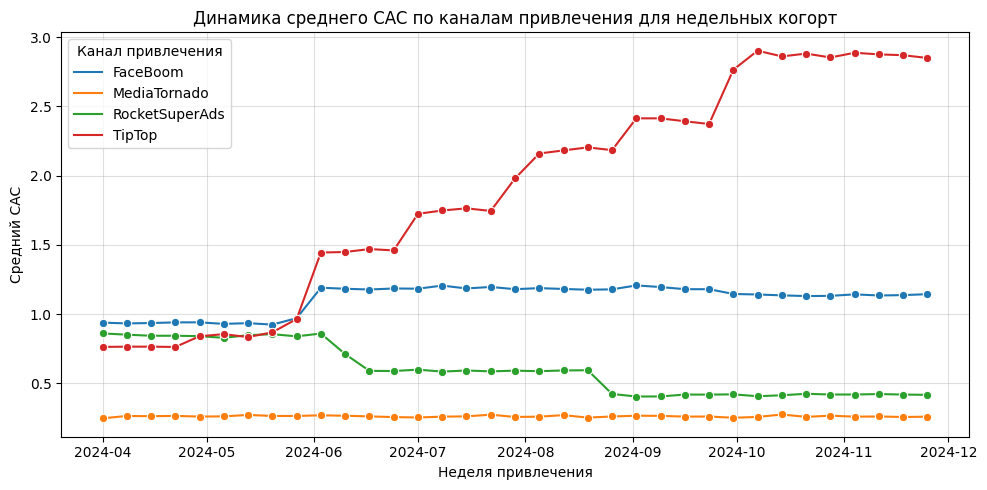

In [40]:
# Считаем средний CAC для каждого канала по недельным когортам
cohort_CAC = profiles.groupby(['first_channel', 'first_week'], as_index=False).agg(avg_CAC=('CAC', 'mean'),
                                                                                   user_count=('user_id', 'count'))

# Рисуем график маркетинговых затрат по каналам для недельных когорт
plt.figure(figsize=(10,5))
sns.lineplot(
    data=cohort_CAC,
    x='first_week',
    y='avg_CAC',
    hue='first_channel',
    marker='o'
)

# Настройки отображения
plt.grid(alpha=.4)
plt.legend(title='Канал привлечения')
plt.title('Динамика среднего CAC по каналам привлечения для недельных когорт')
plt.xlabel('Неделя привлечения')
plt.ylabel('Средний CAC')
plt.tight_layout()

- Для детализации визуализируем метрики `LTV` и `ROI` не только линейными графкими, но и тепловыми картами.

In [41]:
# Отфильтровываем 28 дней активности и считаем суммарную выручку для каналов, когорт и дней активности
cohorts_revenue = orders[orders['days_delta'].between(0,28)].groupby(['first_channel', 'first_week'], as_index=False)['revenue'].sum()

# Объединяем таблицы и считаем LTV
cohort_LTV_CAC = pd.merge(cohorts_revenue, cohort_CAC, on=['first_channel', 'first_week'])
cohort_LTV_CAC['LTV'] = cohort_LTV_CAC['revenue'] / cohort_LTV_CAC['user_count']

# Исключаем последние 4 когорты, потому что они не могли успеть набрать 28 дней активности
cohort_list = cohort_LTV_CAC['first_week'].unique()[-4:]
cohort_LTV_CAC = cohort_LTV_CAC[~cohort_LTV_CAC['first_week'].isin(cohort_list)]

# Для отображения на тепловых картах меняем формат строки
cohort_LTV_CAC['first_week'] = cohort_LTV_CAC['first_week'].astype(str)

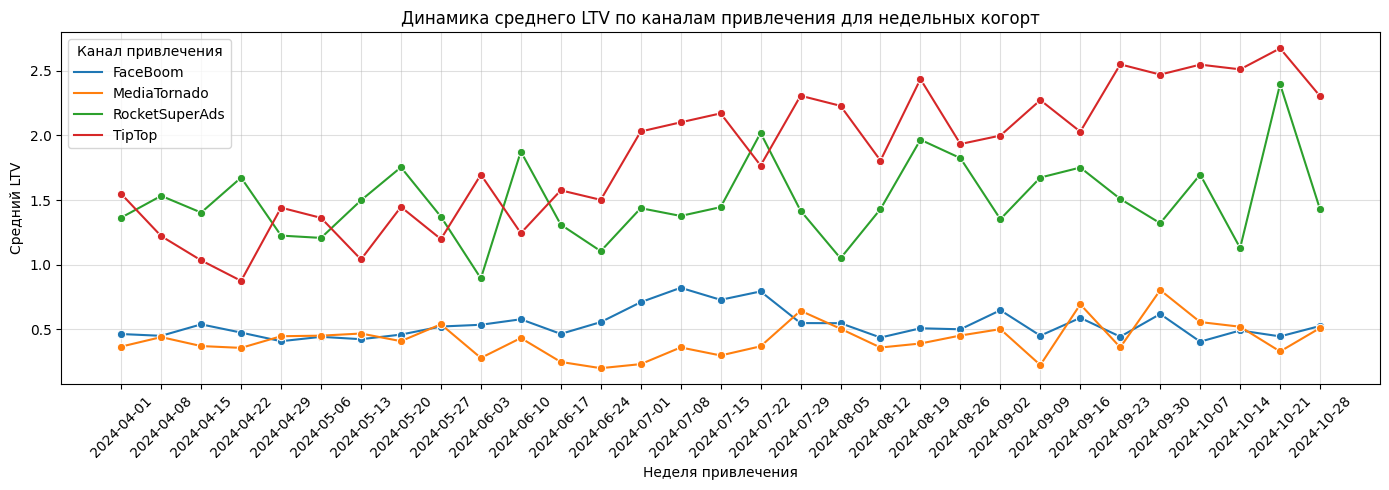

In [42]:
# Рисуем график
plt.figure(figsize=(14,5))
sns.lineplot(
    data=cohort_LTV_CAC,
    x='first_week',
    y='LTV',
    hue='first_channel',
    marker='o'
)

# Настройки отображения
plt.grid(alpha=.4)
plt.legend(title='Канал привлечения')
plt.xticks(rotation=45)
plt.title('Динамика среднего LTV по каналам привлечения для недельных когорт')
plt.xlabel('Неделя привлечения')
plt.ylabel('Средний LTV')
plt.tight_layout()

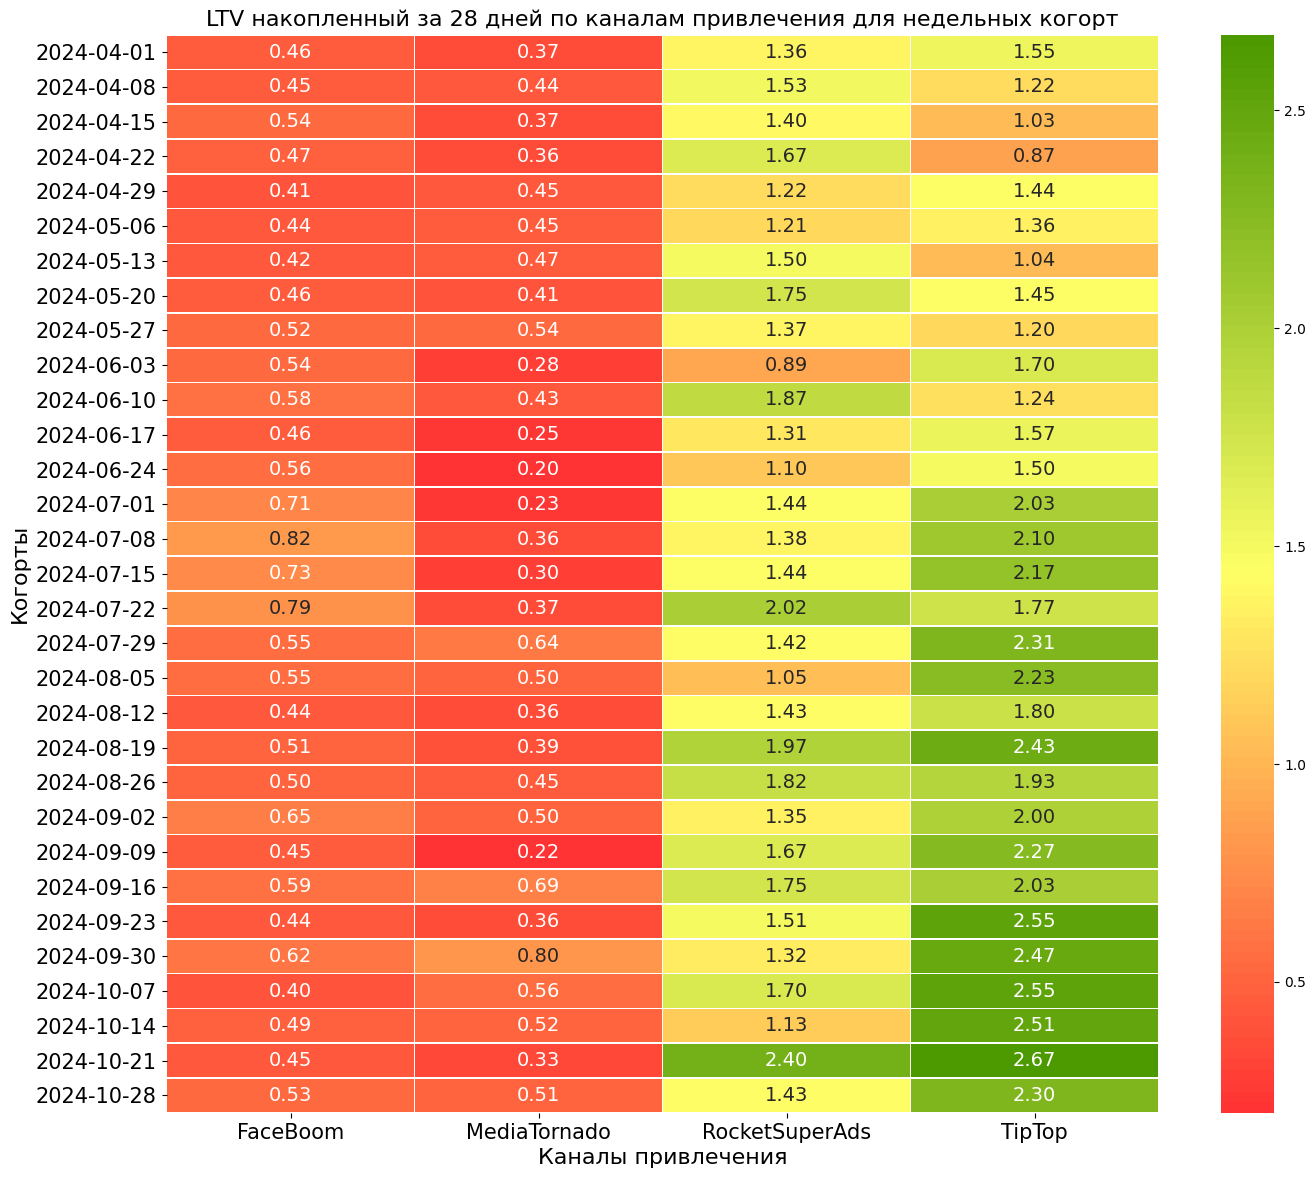

In [43]:
# Пивотируем данные
pivot_table = pd.pivot(
    cohort_LTV_CAC,
    index='first_week',
    columns='first_channel',
    values='LTV'
)

# Рисуем тепловую карту
plt.subplots(figsize=(16,14))
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)
sns.heatmap(
    pivot_table,
    cmap=cmap,
    annot=True,
    fmt='.2f',
    linewidth=0.5,
    annot_kws={"size": 14}
)

plt.title('LTV накопленный за 28 дней по каналам привлечения для недельных когорт', fontsize=16)
plt.xlabel('Каналы привлечения', fontsize=16)
plt.ylabel('Когорты', fontsize=16)
plt.yticks(rotation=0)
plt.tick_params(labelsize=15)

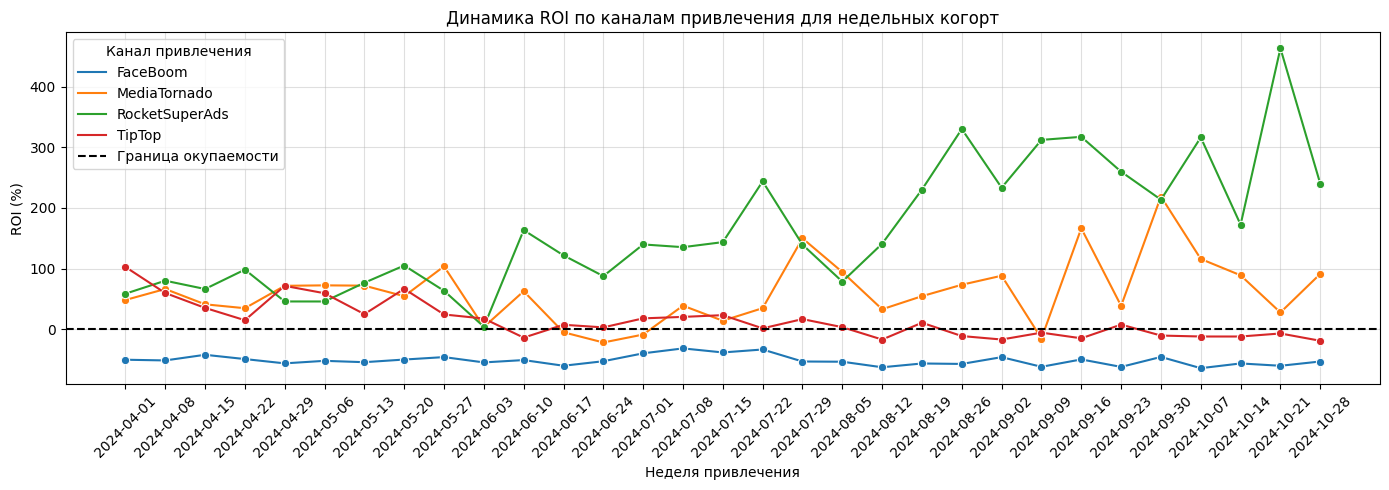

In [44]:
# Считаем ROI
cohort_LTV_CAC['ROI'] = (cohort_LTV_CAC['LTV'] - cohort_LTV_CAC['avg_CAC']) / cohort_LTV_CAC['avg_CAC'] * 100

# Рисуем график
plt.figure(figsize=(14,5))
sns.lineplot(
    data=cohort_LTV_CAC,
    x='first_week',
    y='ROI',
    hue='first_channel',
    marker='o'
)

# Рисуем линию окупаемости y=0
plt.axhline(y=0, color='black', linestyle='--', label='Граница окупаемости')

# Настройки отображения
plt.grid(alpha=.4)
plt.legend(title='Канал привлечения')
plt.xticks(rotation=45)
plt.title('Динамика ROI по каналам привлечения для недельных когорт')
plt.xlabel('Неделя привлечения')
plt.ylabel('ROI (%)')
plt.tight_layout()

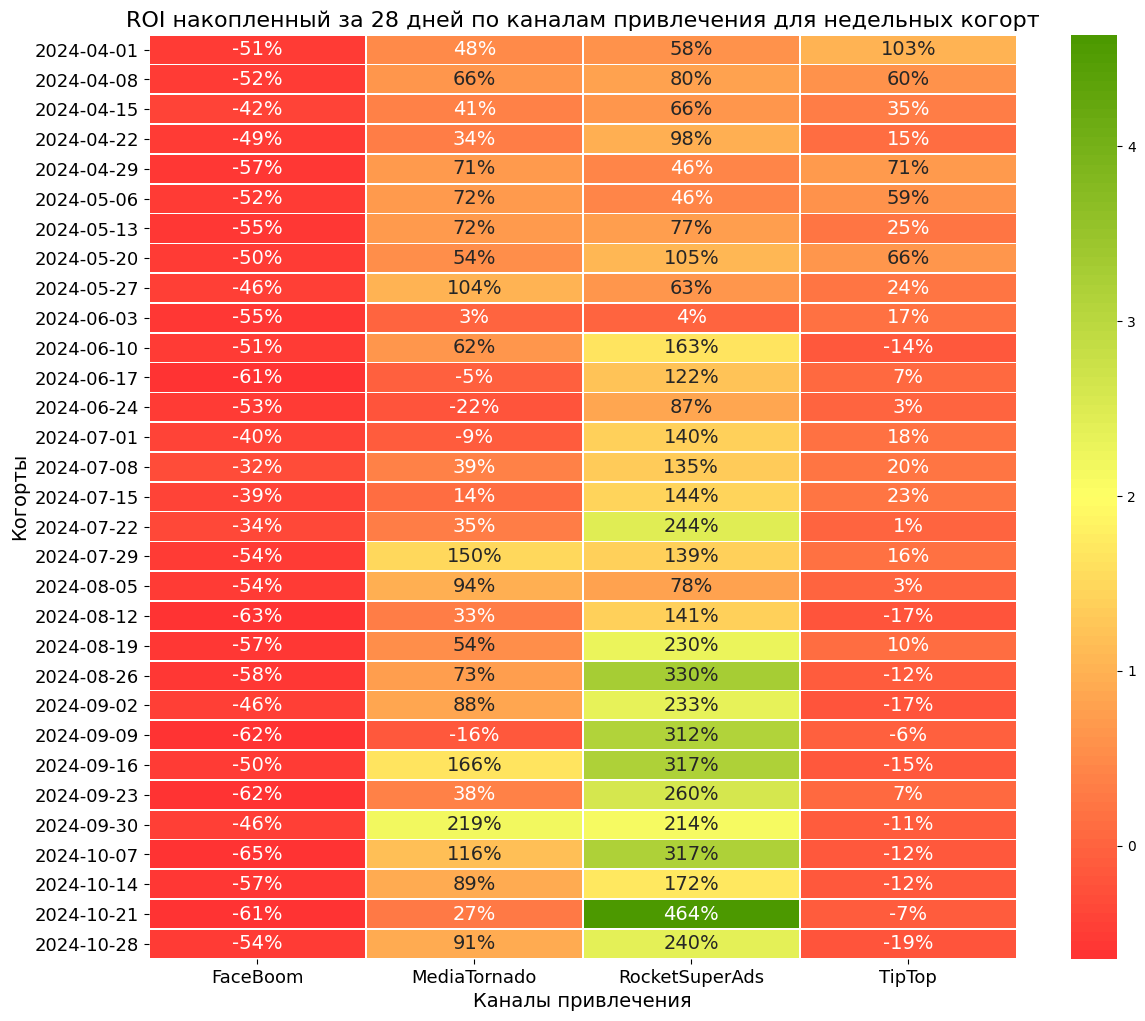

In [45]:
# Делим на 100 для отображения на тепловой карте в процентах
cohort_LTV_CAC['ROI'] = cohort_LTV_CAC['ROI'] / 100

# Пивотируем данные
pivot_table = pd.pivot(
    cohort_LTV_CAC,
    index='first_week',
    columns='first_channel',
    values='ROI'
)

# Рисуем тепловую карту
plt.subplots(figsize=(14,12))
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)
sns.heatmap(
    pivot_table,
    cmap=cmap,
    annot=True,
    fmt='.0%',
    linewidth=0.5,
    annot_kws={"size": 14}
)

plt.title('ROI накопленный за 28 дней по каналам привлечения для недельных когорт', fontsize=16)
plt.xlabel('Каналы привлечения', fontsize=14)
plt.ylabel('Когорты', fontsize=14)
plt.yticks(rotation=0)
plt.tick_params(labelsize=13)

**Выводы:**
- По каналу привлечения `FaceBoom` ни одна недельная когорта не окупилась за 28 дней. Этот источник приходится сравнительно среднее количество затрат и пользователи по нему приходят одни из самых не активных со средненькой конверсией в покупку, что не окупает затраты.
- По каналу `MediaTornado` окупились почти все недельные когорты. Была заметна просадка по окупаемости в первой половине лета, возможно это связанно с появлением нового контента. На тепловой карте так же видно, что этот источник один из самых нестабильных. Так же стоит отметить, что у этого канала самая низкая конверсия в покупку, но и самые низкие затраты на привлечение.
- Рекламный источник `RocketSuperAds` на втором месте по накопленному LTV, но на первом по окупаемости. Динамика CAC и затрат на этот канал показывают, что в среднем каждый пользователь обходится все дешевле, а выручка с него в среднем почти не меняется. Все это приводит к тому, что окупаемость, после резкой просадки в начале лета, в среднем растет. Просадка видимо связана с добавлением нового контента, возможно пришло большое количество новый пользователей, которые не стали покупателями.
- Канал `TipTop`, хоть и привлекает самую активную и платящую аудиторию, довольно сильно вырос в расходах. Это привело к тому, что с конца лета он вообще перестал окупаться за 28 дней.

## Анализ периода окупаемости маркетинговых вложений

Для источников, которые к 28-му дню не выходят на уровень окупаемости, рассчитаем и визуализируем в виде тепловой карты значения накопительного ROI за больший период, например за 8–10 недель.

Разделим данные на недельные когорты по дате привлечения, в качестве интервала наблюдений используем недели.

In [46]:
# Добавляем поле с обозначением недели, в которую произошло событие
orders['event_week'] = orders['event_dt'].dt.to_period('W').dt.to_timestamp()

# Добавляем поле с разницей между неделей события и первой неделей
orders['week_delta'] = (
    orders['event_week'].dt.to_period('W').astype('int') - orders['first_week'].dt.to_period('W').astype('int')
)

# Фильтруем датасеты для каналов привлечения, которые в последнее время не окупаются за 28 дней
channels = ['FaceBoom', 'TipTop']
orders_filt = orders[(orders['first_channel'].isin(channels)) &
                     (orders['week_delta']).between(0,10)]
cohort_CAC_filt = cohort_CAC[cohort_CAC['first_channel'].isin(channels)]

# Считаем суммарную выручку по неделям для каждого канала привлечения по недельным когортам
cohort_revenue = orders_filt.groupby(['first_channel', 'first_week', 'week_delta'], as_index=False)['revenue'].sum()

# Отсортируем таблицу и посчтаем кумулятивную сумму выручки
cohort_revenue.sort_values(by=['first_channel', 'first_week', 'week_delta'], inplace=True)
cohort_revenue['revenue_cumsum'] = cohort_revenue.groupby(['first_channel', 'first_week'])['revenue'].cumsum()

# Объединяем таблицы и считаем LTV
cohort_LTV_CAC = pd.merge(cohort_revenue, cohort_CAC_filt, on=['first_channel', 'first_week'])
cohort_LTV_CAC['LTV'] = cohort_LTV_CAC['revenue_cumsum'] / cohort_LTV_CAC['user_count']

# Считаем ROI 
cohort_LTV_CAC['ROI'] = (cohort_LTV_CAC['LTV'] - cohort_LTV_CAC['avg_CAC']) / cohort_LTV_CAC['avg_CAC']

# Форматируем поле first_week в строку, для отображения на тепловой карте
cohort_LTV_CAC['first_week'] = cohort_LTV_CAC['first_week'].astype(str)

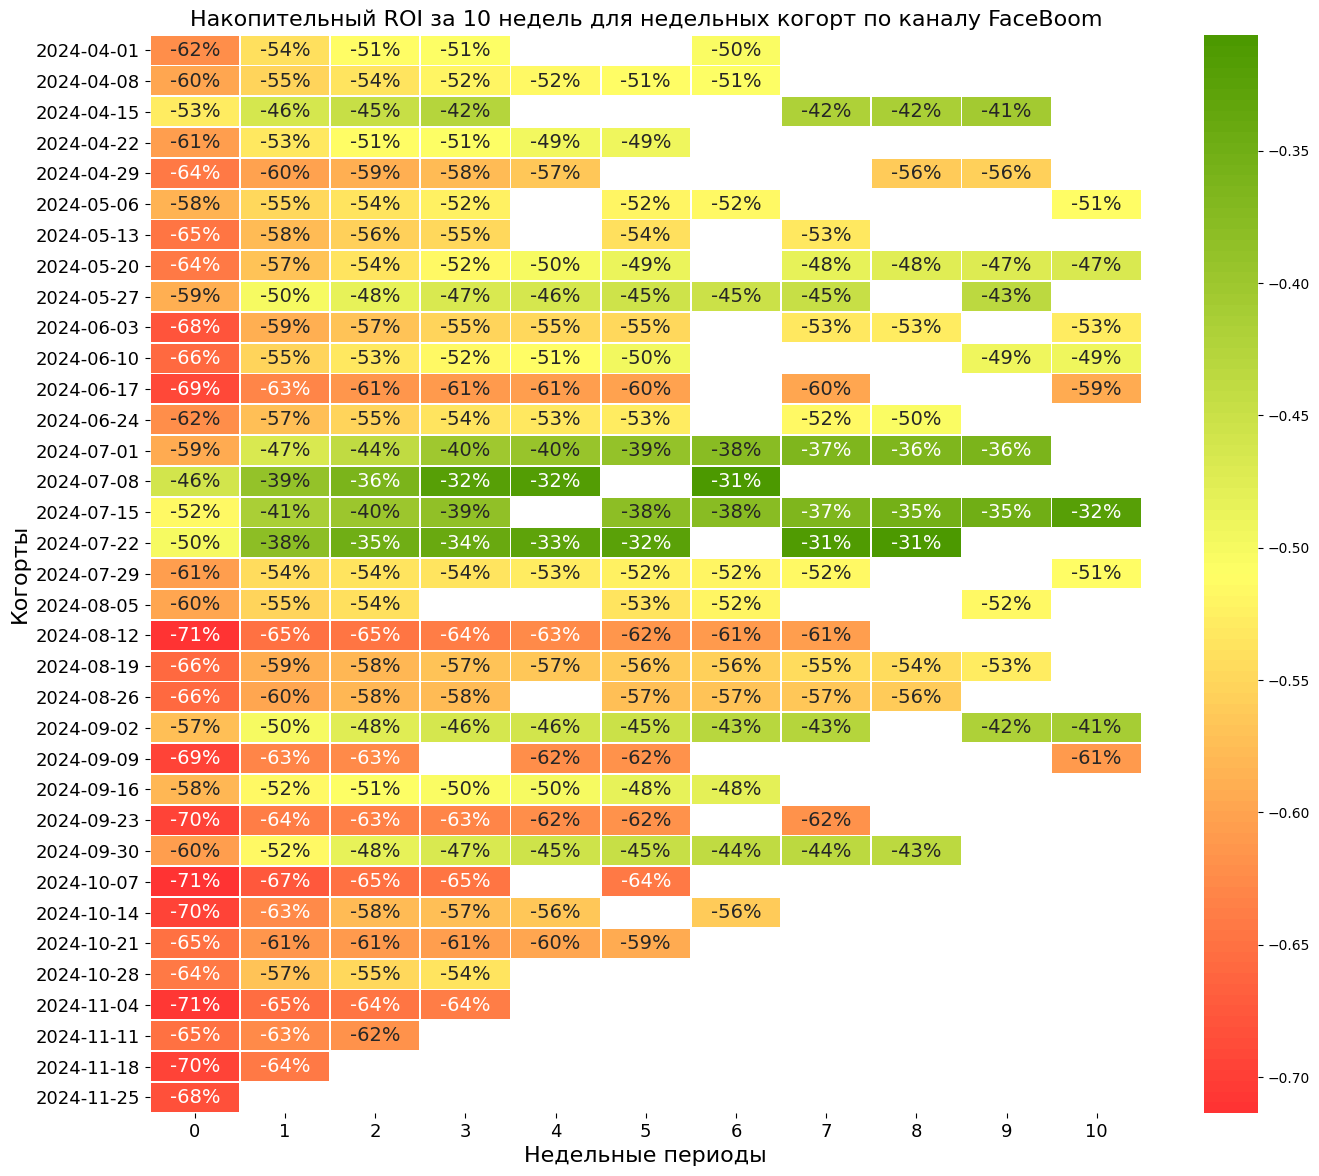

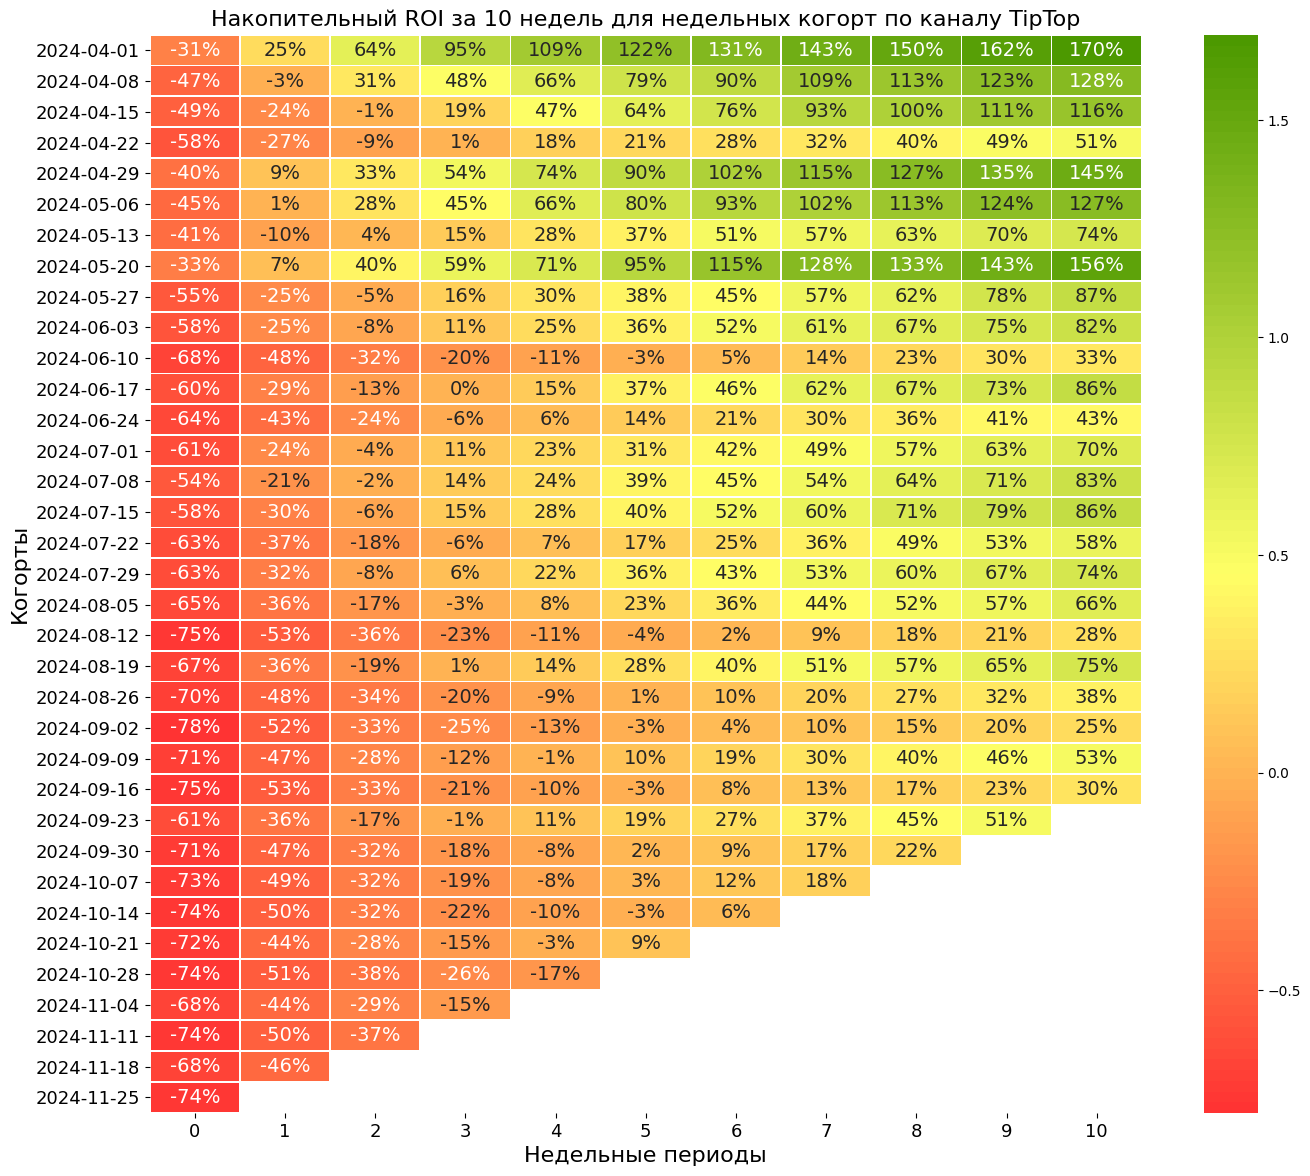

In [47]:
# Палитра цветов для тепловой карты
cmap = mcolors.LinearSegmentedColormap.from_list('green_red', ['#FF3333', '#FFFF66', '#4C9900'], N=100)

# Строим две тепловые карты через цикл
for channel in cohort_LTV_CAC['first_channel'].unique():
    df_plot = cohort_LTV_CAC[cohort_LTV_CAC['first_channel']==channel]

    pivot_data = pd.pivot_table(
        df_plot,
        index='first_week',
        columns='week_delta',
        values='ROI'
    )

    plt.subplots(figsize=(16,14))
    sns.heatmap(
        pivot_data,
        cmap=cmap,
        annot=True,
        fmt='.0%',
        linewidth=0.5,
        annot_kws={"size": 14}
    )
    
    plt.title(f'Накопительный ROI за 10 недель для недельных когорт по каналу {channel}', fontsize=16)
    plt.xlabel('Недельные периоды', fontsize=16)
    plt.ylabel('Когорты', fontsize=16)
    plt.yticks(rotation=0)
    plt.tick_params(labelsize=13)

**Выводы:**
- Ни одна недельная когорта по каналу привлечения `FaceBoom` не выходит на уровень окупаемости даже за 10 недель. Так же можно отметить, что в тепловой карте есть пробелы, т.е. у некоторых когорт в какие-то недели по этому трафику не было никакой выручки. При этом метрика `ROI` в последнее время не ухудшалась, т.е. этот канал просто всегда был таким. Было только некоторое улучшение метрики в июле, но до окупаемости дело так и не дошло.
- Окупаемость канала привлечения `TipTop` заметно просела в конце мая - начале июня. Если раньше, в апреле например, метрика `ROI` могла выйти в плюс уже на первый-второй период, то летние и осенние когорты выходят в плюс только на пятый-шестой период.

## Выводы и рекомендации

**Общие выводы:**
- Канал `TipTop` привлекает самую активную и платящую аудиторию, но, из-за увеличивающихся затрат, он уже не успевает окупаться за 4 недели. Видимо нужно снижать финансирование этого источника.
- Канал `FaceBoom` вообще никогда не был прибыльным и не окупался даже за 10 недель. Мне кажется, про него лучше забыть.
- Каналы `MediaTornado` и `RocketSuperAds` привлекают среднюю по всем параметрам и схожую, тоже по всем параметрам, аудиторию. Возможно кроме конверии в покупку - у `RocketSuperAds` она немного больше. Эти источники довольно стабильно окупаются. У `MediaTornado` было только четыре недельных когорты, которые не успели окупиться за 28 дней. У `RocketSuperAds` же окупились все недельные когорты и выручка в последнее время в среднем растет.

По всей видимости выручка начала стагнировать из-за канала привлечения `TipTop`, который в последние месяцы перестал окупаться за 28 дней. Канал `FaceBoom` никогда не окупался, вряд ли выручка начала стагнировать из-за него.

**Рекомендации:**
- Снизить затраты на канал привлечения `TipTop`. Он перестал успевать окупаться за 28 дней.
- В канал `FaceBoom` нужно перестать вкладываться.
- Канал `MediaTornado`, хоть и почти всегда окупается, выглядит довольно нестабильным. Возможно с этим можно что-то сделать.
- У канала `RocketSuperAds` дела идут хорошо, от снижения трат на него доход только увеличился. Не думаю, что с ним что-то нужно делать.